In [2]:
import os
import xarray as xr
import functions.MLD_4grp_cmip as fl_mld
import matplotlib.pyplot as plt
import gsw
import numpy as np
import functions.mld_calculations as cmip_mld
from multiprocessing import Pool
import re
import scipy.io as sio
import functions.MLD_4grp_cmip as fl_mld



In [3]:
# directories

data_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Datasets/"
# cmip_dir = data_dir + "Model_Output/CMIP5/"

# model_run = 'cmip5'
# model_run = 'cmip6_historical'
# model_run = 'cmip6_ssp585'

model_categories = {'cmip5', 'cmip6_historical', 'cmip6_ssp585'}
# model_categories = {'SOSE_i133', 'SOSE_i154'}
# model_categories = {'SOSE_i133'}

var_names = {'so', 'thetao'}
# model_categories = {'cmip5', 'cmip6_historical'}
# model_categories = {'cmip5'}

rerun_flag = 0 # whether to only process if the output MLD file does not exist

In [51]:
# checking GISS model output

var = 'dissic'
# var_n = xr.open_dataset(data_dir + 'Model_Output/CMIP6/dissic/monthly/historical_download/original_files/dissic_Omon_GFDL-ESM4_historical_r1i1p1f1_gr_201001-201412.nc')
# var_giss = xr.open_dataset(data_dir + 'Model_Output/CMIP6/dissic/monthly/historical_download/original_files/dissic_Omon_GISS-E2-1-G_historical_r101i1p1f1_gn_201101-201412.nc')

# var_n = xr.open_dataset(data_dir + 'Model_Output/CMIP6/' + var + '/historical_download/original_files/intpp_Omon_GFDL-ESM4_historical_r1i1p1f1_gr_201001-201412.nc')
# var_giss = xr.open_dataset(data_dir + 'Model_Output/CMIP6/' + var + '/historical_download/intpp_Omon_GISS-E2-1-G_historical_r101i1p1f1_gn_200101-201412.nc')

# var_n = xr.open_dataset(data_dir + 'Model_Output/CMIP6/' + var + '/historical_download/original_files/' + var + '_Omon_GFDL-ESM4_historical_r1i1p1f1_gr_201001-201412.nc')
# var_giss = xr.open_dataset(data_dir + 'Model_Output/CMIP6/' + var + '/historical_download/' + var + '_Omon_GISS-E2-1-G_historical_r101i1p1f1_gn_200101-201412.nc')

var_1 = xr.open_dataset(data_dir + 'Model_Output/CMIP6/' + var + '/monthly/ssp585_download/dissic_Omon_GISS-E2-1-G_ssp585_r101i1p1f1_gn_201501-202412.nc')
var_2 = xr.open_dataset(data_dir + 'Model_Output/CMIP6/' + var + '/monthly/ssp585_download/original_files/dissic_Omon_GFDL-CM4_ssp585_r1i1p1f1_gr_201501-203412.nc')

In [52]:
print(var_1[var])
print(var_2[var])

<xarray.DataArray 'dissic' (time: 120, lev: 40, lat: 180, lon: 288)>
[248832000 values with dtype=float32]
Coordinates:
  * time     (time) object 2015-01-16 12:00:00 ... 2024-12-16 12:00:00
  * lev      (lev) float64 5.0 16.0 29.0 44.0 ... 4.453e+03 4.675e+03 4.897e+03
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1 359.4
Attributes:
    standard_name:  mole_concentration_of_dissolved_inorganic_carbon_in_sea_w...
    long_name:      Dissolved Inorganic Carbon Concentration
    comment:        Dissolved inorganic carbon (CO3+HCO3+H2CO3) concentration
    units:          mol m-3
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello
    history:        2024-09-20T14:13:47Z altered by CMOR: replaced missing va...
<xarray.DataArray 'dissic' (time: 240, lev: 35, lat: 180, lon: 360)>
[544320000 values with dtype=float32]
Coordinates:
  * lat      (lat) f

In [13]:
var_1[var].attrs['units']

'mol m-2 s-1'

In [18]:
var_1.time[0]

<xarray.DataArray 'time' ()>
array(cftime.DatetimeNoLeap(2010, 1, 16, 12, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 2010-01-16 12:00:00
Attributes:
    long_name:      time
    axis:           T
    calendar_type:  noleap
    bounds:         time_bnds
    standard_name:  time
    description:    Temporal mean

In [67]:
tt=0
var_1.attrs['source_id']
var_1.attrs['experiment_id']

'ssp585'

In [71]:
str(var_1['time'][0].values)

'2015-01-16 12:00:00'

In [57]:
var_n.attrs['parent_source_id'] + ' max: ' + str(round(np.nanmax(temp_vals),1)) + ' min: ' + str(round(np.nanmin(temp_vals),1)) + ' median: ' + str(round(np.nanmedian(temp_vals),1) )

'GFDL-ESM4 max: 3.3 min: 0.3 median: 2.1'

In [91]:
vec_1 = np.reshape(temp_1,(1,-1))


(1, 64800)

In [ ]:
tt = 0

# temp_1 = var_1[var][tt,:,:].values
# vec_1 = np.reshape(temp_1,(1,-1))

# temp_2 = var_2[var][tt,:,:].values
# vec_2 = np.reshape(temp_2,(1,-1))
# n = 10

# print(var_1.attrs['parent_source_id'] + ' max: ' + str(round(np.nanmax(temp_1),n)) + ' min: ' + str(round(np.nanmin(temp_1),n)) + ' median: ' + str(round(np.nanmedian(temp_1),n) ))
# print(var_2.attrs['parent_source_id'] + ' max: ' + str(round(np.nanmax(temp_2),n)) + ' min: ' + str(round(np.nanmin(temp_2),n)) + ' median: ' + str(round(np.nanmedian(temp_2),n) ))


# plt.subplot(1,2,1)
# plt.hist(vec_1)
# plt.title(var_1.attrs['source_id'] + ' \n' + var_1.attrs['experiment_id'] + ' ' + str(var_1['time'][tt].values))
# plt.xlabel(var_1[var].attrs['original_name'] + ' ' + var_1[var].attrs['units'])

# plt.subplot(1,2,2)
# plt.hist(vec_2)
# plt.title(var_2.attrs['source_id'] + ' \n' + var_2.attrs['experiment_id'] + ' ' + str(var_2['time'][tt].values))
# plt.xlabel(var_2[var].attrs['units'])
# plt.tight_layout()

GFDL-ESM4 max: 5e-09 min: -1.05e-08 median: 1e-10
GISS-E2-1-G max: 6e-09 min: -6.5e-09 median: 0.0


/Users/smb-uh/opt/anaconda3/envs/cmip_processing/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Users/smb-uh/opt/anaconda3/envs/cmip_processing/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


KeyboardInterrupt: 

In [33]:
var_1.attrs

{'Conventions': 'CF-1.7 CMIP-6.2',
 'activity_id': 'CMIP',
 'branch_method': 'standard',
 'branch_time_in_child': 0.0,
 'branch_time_in_parent': 0.0,
 'contact': 'Kenneth Lo (cdkkl@giss.nasa.gov)',
 'creation_date': '2020-11-02T23:53:59Z',
 'data_specs_version': '01.00.23',
 'experiment': 'all-forcing simulation of the recent past',
 'experiment_id': 'historical',
 'external_variables': 'areacello',
 'forcing_index': 1,
 'frequency': 'mon',
 'further_info_url': 'https://furtherinfo.es-doc.org/CMIP6.NASA-GISS.GISS-E2-1-G.historical.none.r101i1p1f1',
 'grid': 'atmospheric grid: 144x90, ocean grid: 288x180',
 'grid_label': 'gn',
 'history': '2020-11-02T23:53:59Z ; CMOR rewrote data to be consistent with CMIP6, CF-1.7 CMIP-6.2 and CF standards.',
 'initialization_index': 1,
 'institution': 'Goddard Institute for Space Studies, New York, NY 10025, USA',
 'institution_id': 'NASA-GISS',
 'mip_era': 'CMIP6',
 'model_id': 'Egigcc_exp25',
 'nominal_resolution': '250 km',
 'parent_activity_id': '

/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_63029/1771439224.py:19: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  c2 = plt.colorbar()


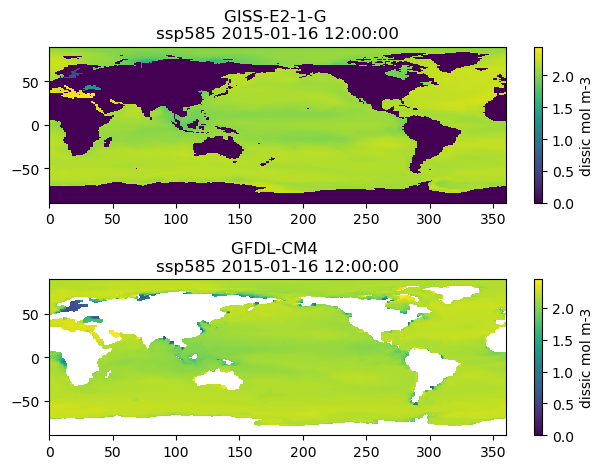

In [53]:
tt=0
temp_1 = var_1[var][tt,0,:,:]
temp_2 = var_2[var][tt,0,:,:]

fig = plt.figure()

plt.subplot(2,1,1)
plt.pcolor(temp_1.lon, temp_1.lat, temp_1, vmin=np.nanmin(temp_1), vmax = np.nanmax(temp_1))
# plt.pcolor(temp_1.lon, temp_1.lat, temp_1)

c1 = plt.colorbar()
c1.set_label(var_1.attrs['variable_id'] + ' ' + var_1[var].attrs['units'])
plt.title(var_1.attrs['source_id'] + ' \n' + var_1.attrs['experiment_id'] + ' ' + str(var_1['time'][tt].values))

plt.subplot(2,1,2)
plt.pcolor(temp_2.lon, temp_2.lat, temp_2, vmin=np.nanmin(temp_1), vmax = np.nanmax(temp_1))
# plt.pcolor(temp_2.lon, temp_2.lat, temp_2)

c2 = plt.colorbar()
c2.set_label(var_2.attrs['variable_id'] + ' ' + var_2[var].attrs['units'])

plt.title(var_2.attrs['source_id'] + ' \n' + var_2.attrs['experiment_id'] + ' ' + str(var_2['time'][tt].values))
plt.tight_layout()


In [32]:
temp_vals

<xarray.DataArray 'dissic' (lat: 180, lon: 360)>
array([[     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       ...,
       [2.15623 , 2.156183, 2.156158, ..., 2.15634 , 2.156301, 2.156262],
       [2.14944 , 2.149431, 2.149422, ..., 2.149462, 2.149456, 2.149441],
       [2.143569, 2.143533, 2.143501, ..., 2.143642, 2.143632, 2.143602]],
      dtype=float32)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
    time     object 2010-01-16 12:00:00
    lev      float64 2.5
Attributes:
    long_name:      Dissolved Inorganic Carbon Concentration
    units:          mol m-3
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    standard_name:  mole_concentration_of_dissolved_inorganic_carbon_in_sea_w...
    interp_method:  conserve_order1
    original_name:  dissic
    comment:        Model data on the 1x1 grid includes values in all cells f...

In [42]:
var_giss[var].attrs

{'standard_name': 'mole_concentration_of_dissolved_inorganic_carbon_in_sea_water',
 'long_name': 'Dissolved Inorganic Carbon Concentration',
 'comment': 'Dissolved inorganic carbon (CO3+HCO3+H2CO3) concentration',
 'units': 'mol m-3',
 'cell_methods': 'area: mean where sea time: mean',
 'cell_measures': 'area: areacello',
 'history': '2019-08-29T17:04:34Z altered by CMOR: replaced missing value flag (-1e+30) with standard missing value (1e+20).'}

/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_54481/2359980637.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  c1 = plt.colorbar()


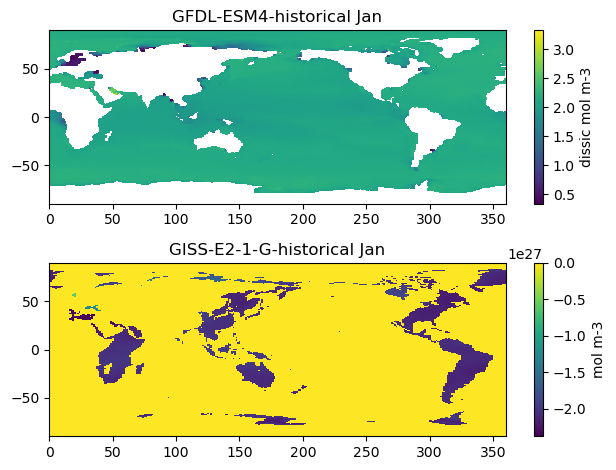

In [44]:
temp_vals = var_n[var][0,0,:,:]
temp_giss = var_giss[var][0,0,:,:]

fig = plt.figure()

plt.subplot(2,1,1)
plt.pcolor(temp_vals.lon, temp_vals.lat, temp_vals)
c1 = plt.colorbar()
c1.set_label(var_n[var].attrs['original_name'] + ' ' + var_n[var].attrs['units'])
plt.title('GFDL-ESM4-historical Jan')

plt.subplot(2,1,2)
plt.pcolor(temp_giss.lon, temp_giss.lat, temp_giss)
c2 = plt.colorbar()
c2.set_label(var_giss[var].attrs['units'])

plt.title('GISS-E2-1-G-historical Jan')
plt.tight_layout()

In [89]:
# check for vertical coordinates of rho, instead of lev

for model_run in model_categories:

    if model_run=='cmip5':
        cmip_dir = data_dir + "Model_Output/CMIP5/"
        experiment = 'rcp85'
        dir_add_on = ''
    elif model_run=='cmip6_historical':
        cmip_dir = data_dir + "Model_Output/CMIP6/"
        experiment = 'historical'
        dir_add_on = 'historical_download/'
    elif model_run=='cmip6_ssp585':
        cmip_dir = data_dir + "Model_Output/CMIP6/"
        experiment = 'ssp585'
        dir_add_on = 'ssp585_download/'
    elif model_run=='SOSE_i133':
        cmip_dir = data_dir + "Model_Output/2013-2018_ITER133_1_6deg/"
        experiment = 'i133'
        dir_add_on = '/'
    for var in var_names:
        # print(model_name + ' ' + model_run)

        for file in os.listdir(cmip_dir + var + '/' +  dir_add_on + '/original_files/'):
            # print(file)
            if file.endswith('.nc'):
                var_n = xr.open_dataset(cmip_dir + var + '/' +  dir_add_on + '/original_files/' + file)

                print(file + ' ' + var + ' ' + model_run)

                for k in  var_n[var].indexes.keys():
                    if k!='time' and k!='lat' and k!='lon' and k!='x' and k!='y' and k!='i' and k!='j':
                        print(k)
            # if '_' + model_name + '_' in file:
            #     so_filename = file

        # for file in os.listdir(cmip_dir + 'thetao/regrid_for_MLD/' + dir_add_on):
        #         if '_' + model_name + '_' in file:
        #             thetao_filename = file


      
        # thetao_n = xr.open_dataset(cmip_dir + 'thetao/regrid_for_MLD/' + dir_add_on + thetao_filename)


        # for k in  thetao_n.thetao.indexes.keys():
        #     if k!='time' and k!='lat' and k!='lon':
        #         print(k)

        

so_Omon_CNRM-ESM2-1_historical_r1i1p1f2_gn_200001-201412.nc so cmip6_historical
lev
so_Omon_MRI-ESM2-0_historical_r1i2p1f1_gr_195001-201412.nc so cmip6_historical
lev
so_Omon_CESM2-WACCM_historical_r1i1p1f1_gr_185001-201412.nc so cmip6_historical
lev
so_Omon_GFDL-ESM4_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
lev
so_Omon_CMCC-ESM2_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
lev
so_Omon_MIROC-ES2L_historical_r1i1p1f2_gn_185001-201412.nc so cmip6_historical
lev
so_Omon_ACCESS-ESM1-5_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
lev
so_Omon_NorESM2-LM_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
rho
so_Omon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
lev
so_Omon_CanESM5_historical_r1i1p2f1_gn_200101-201412.nc so cmip6_historical
lev
so_Omon_MPI-ESM1-2-HR_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
lev
so_Omon_CanESM5-1_historical_r1i1p1f1_gn_200101-201412.nc so cmip6_historical
lev

/Users/smb-uh/opt/anaconda3/envs/float_bgc_synthesis_products/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'so' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/smb-uh/opt/anaconda3/envs/float_bgc_synthesis_products/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'so' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


so_Omon_NorESM2-MM_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
rho
so_Omon_INM-CM4-8_historical_r1i1p1f1_gr1_201001-201412.nc so cmip6_historical
lev
so_Omon_GFDL-CM4_historical_r1i1p1f1_gn_201001-201412.nc so cmip6_historical
lev
thetao_Omon_INM-CM4-8_historical_r1i1p1f1_gr1_201001-201412.nc thetao cmip6_historical
lev
thetao_Omon_NorESM2-MM_historical_r1i1p1f1_gn_201001-201412.nc thetao cmip6_historical
rho
thetao_Omon_CESM2-WACCM_historical_r1i1p1f1_gr_185001-201412.nc thetao cmip6_historical
lev
thetao_Omon_CanESM5_historical_r1i1p2f1_gn_200101-201412.nc thetao cmip6_historical
lev
thetao_Omon_GFDL-CM4_historical_r1i1p1f1_gr_201001-201412.nc thetao cmip6_historical
lev
thetao_Omon_CNRM-ESM2-1_historical_r1i1p1f2_gn_200001-201412.nc thetao cmip6_historical
lev
thetao_Omon_CanESM5-1_historical_r1i1p1f1_gn_200101-201412.nc thetao cmip6_historical
lev
thetao_Omon_GFDL-ESM4_historical_r1i1p1f1_gr_201001-201412.nc thetao cmip6_historical
lev
thetao_Omon_CanESM5-CanOE_hist

/Users/smb-uh/opt/anaconda3/envs/float_bgc_synthesis_products/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'thetao' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/smb-uh/opt/anaconda3/envs/float_bgc_synthesis_products/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'thetao' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


thetao_Omon_CESM2_historical_r4i1p1f1_gn_185001-201412.nc thetao cmip6_historical
lev
nlat
nlon
thetao_Omon_BCC-CSM2-MR_historical_r1i1p1f1_gn_201001-201412.nc thetao cmip6_historical
lev
thetao_Omon_AWI-ESM-1-REcoM_historical_r1i1p1f1_gr1_201001-201412.nc thetao cmip6_historical
depth
thetao_Omon_NorESM2-LM_historical_r1i1p1f1_gn_201001-201412.nc thetao cmip6_historical
rho
thetao_Omon_UKESM1-0-LL_historical_r1i1p1f2_gn_200001-201412.nc thetao cmip6_historical
lev
thetao_Omon_NorESM2-MM_historical_r1i1p1f1_gr_201001-201412.nc thetao cmip6_historical
lev
thetao_Omon_MRI-ESM2-0_historical_r1i2p1f1_gr_195001-201412.nc thetao cmip6_historical
lev
thetao_Omon_CMCC-ESM2_historical_r1i1p1f1_gn_201001-201412.nc thetao cmip6_historical
lev
so_Omon_CMCC-ESM2_ssp585_r1i1p1f1_gn_201501-203412.nc so cmip6_ssp585
lev
so_Omon_GFDL-CM4_ssp585_r1i1p1f1_gn_201501-203412.nc so cmip6_ssp585
lev
so_Omon_CanESM5-CanOE_ssp585_r1i1p2f1_gn_201501-202012.nc so cmip6_ssp585
lev
so_Omon_ACCESS-ESM1-5_ssp585_r1i1

/Users/smb-uh/opt/anaconda3/envs/float_bgc_synthesis_products/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'so' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/Users/smb-uh/opt/anaconda3/envs/float_bgc_synthesis_products/lib/python3.9/site-packages/xarray/conventions.py:516: SerializationWarning: variable 'so' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


In [4]:

for model_run in model_categories:

    if model_run=='cmip5':
        cmip_dir = data_dir + "Model_Output/CMIP5/"
        experiment = 'rcp85'
        dir_add_on = ''
        sal_name = 'so'
        theta_name = 'thetao'
        out_dir = 'mld/regrid/'

    elif model_run=='cmip6_historical':
        cmip_dir = data_dir + "Model_Output/CMIP6/"
        experiment = 'historical'
        dir_add_on = 'historical_download/'
        sal_name = 'so'
        theta_name = 'thetao'
        out_dir = 'mld/regrid/'

    elif model_run=='cmip6_ssp585':
        cmip_dir = data_dir + "Model_Output/CMIP6/"
        experiment = 'ssp585'
        dir_add_on = 'ssp585_download/'
        sal_name = 'so'
        theta_name = 'thetao'
        out_dir = 'mld/regrid/'

    elif model_run=='SOSE_i133':
        cmip_dir = data_dir + "Model_Output/SOSE/2013-2018_ITER133_1_6deg/"
        experiment = 'i133'
        dir_add_on = '/'   
        sal_name = 'SALT'
        theta_name = 'THETA'
        out_dir = 'regrid/'

    elif model_run=='SOSE_i154':
        cmip_dir = data_dir + "Model_Output/SOSE/2013-2023_ITER154/"
        experiment = 'i154'
        dir_add_on = '/'   
        sal_name = 'SALT'
        theta_name = 'THETA'
        out_dir = 'regrid/'

    so_file_list = []
    processed_files = os.listdir(cmip_dir + out_dir + dir_add_on)

    for file in os.listdir(cmip_dir + 'so/regrid_for_MLD/' + dir_add_on):
        if file.endswith('.nc'):
            if rerun_flag==1:
                so_file_list.append(file)
            else: # only run files without a MLD file created:
                file_found=0
                for test_file in processed_files:
                    if test_file=='mld' + file[2:]:
                        file_found=1
                if file_found==0:
                    so_file_list.append(file)

    if model_run.__contains__('SOSE'):
        unique_values_list = [experiment]
    else:
        
        # print(so_file_list)
        # get a list of model names
        unique_model_names = set()


        # Regular expression to find the pattern
        pattern = re.compile(r'Omon_(.*?)_'+experiment)

        # Extract the text between "Omon_" and "_rcp85"
        for file_name in so_file_list:
            match = pattern.search(file_name)
            if match:
                unique_model_names.add(match.group(1))

        # Convert the set to a list
        unique_values_list = list(unique_model_names)
    
    # Print the unique values
    print(unique_values_list)

    # unique_values_list = unique_values_list[0:3]
    from importlib import reload
    reload(cmip_mld)

    num_processes = 20

    if __name__ == "__main__":
        
        with Pool(processes=num_processes) as pool:
            # Create a list of arguments for pool.starmap
            if len(unique_values_list)==1:
                cmip_mld.cmip_mld_calc(cmip_dir, out_dir, unique_values_list[0], dir_add_on, sal_name, theta_name, model_run)
            else:
                mld_args = [(cmip_dir, out_dir, model, dir_add_on, sal_name, theta_name, model_run) for n, model in enumerate(unique_values_list)]
            
                # Use pool.starmap with the list of arguments
                pool.starmap(cmip_mld.cmip_mld_calc, mld_args)




['GISS-E2-1-G']
GISS-E2-1-G historical_download/ started
GISS-E2-1-G historical_download/ completed
['GISS-E2-1-G']
GISS-E2-1-G ssp585_download/ started
GISS-E2-1-G ssp585_download/ completed
[]


In [25]:
def sigma0(salinity,temperature,lon,lat,pressure):
    SA = gsw.SA_from_SP(salinity,
                        pressure,
                        lon,
                        lat)

    CT = gsw.CT_from_t(SA,
                       temperature,
                       pressure)

    sigma = gsw.sigma0(SA,CT)
    
    return sigma

ECCO MLD calculations

In [80]:
# ECCO output is in monthly .mat files
ECCO_dir = cmip_dir + '../ECCO_models/ECCOv4r5/'
ECCO_dir
sig_threshold = 0.03

# read in all files for T and S
# want file indices 217 to 336, don't bother creating a real index for now
# os.listdir(ECCO_dir + '/Salt_Intrp_ECCOv4r5/')
for f_num in range(217, 337):
    print(f_num)
    so_n = sio.loadmat(ECCO_dir + '/Salt_Intrp_ECCOv4r5_v2/Salt_Intrp_' + str(f_num) + '_v2.mat')
    to_n = sio.loadmat(ECCO_dir + '/Theta_Intrp_ECCOv4r5_v2/Theta_Intrp_' + str(f_num) + '_v2.mat')

    depth_vals = so_n['depth'].flatten()*-1

    mld_array = np.zeros(to_n['xxc'].shape)
    mld_array[:] = np.NaN
    mld_array.shape
    for lo in range(0, to_n['xxc'].shape[0]):
        for la in range(0, to_n['xxc'].shape[1]):

            pot_dens = sigma0(so_n['S_interp'][lo, la,:], to_n['T_interp'][lo, la,:], so_n['xxc'][lo,la], so_n['yyc'][lo,la], depth_vals)
            pot_dens
            if sum(~np.isnan(pot_dens[depth_vals<=50]))<=1: 
                continue
            mld = fl_mld.calc_mld(pot_dens, depth_vals, ref_depth=10, sigma_theta_crit=sig_threshold)
            mld_array[lo, la] = mld

    so_n['MLD'] = mld_array
    # so_n['MLD']
    # so_n['xxc']
    sio.savemat(ECCO_dir + 'MLD_Intrp_ECCOv4r5/MLD_Intrp_' + str(f_num) + '.mat', so_n)

217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336


Unused code below: 


In [75]:
lo = 320
la = 1
pot_dens = sigma0(so_n['S_interp'][lo, la,:], to_n['T_interp'][lo, la,:], so_n['xxc'][lo,la], so_n['yyc'][lo,la], depth_vals)
print(pot_dens)
if sum(~np.isnan(pot_dens[depth_vals<=50])<=1):
    mld = fl_mld.calc_mld(pot_dens, depth_vals, ref_depth=10, sigma_theta_crit=sig_threshold)
    print(mld)

[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
 27.70805345 27.70437461 27.71892574 27.77058861 27.80275983 27.81399453
         nan         nan         nan         nan         nan         nan
         nan         nan]
849.74


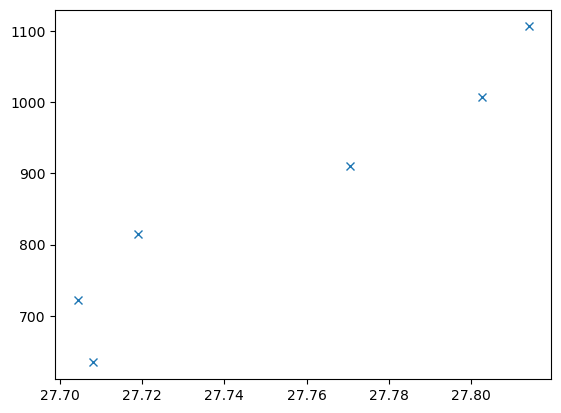

In [70]:
plt.plot(pot_dens, depth_vals,'x')
# plt.plot(27.05, 39.2, 'x')

In [12]:
# testing
# for model_name in unique_values_list:
# model_name = unique_values_list[-1]
model_name = 'MIROC-ESM'
model_run='cmip5'

if model_run=='cmip5':
    cmip_dir = data_dir + "Model_Output/CMIP5/"
    experiment = 'rcp85'
    dir_add_on = ''
    sal_name = 'so'
    theta_name = 'thetao'
elif model_run=='cmip6_historical':
    cmip_dir = data_dir + "Model_Output/CMIP6/"
    experiment = 'historical'
    dir_add_on = 'historical_download/'
    sal_name = 'so'
    theta_name = 'thetao'
elif model_run=='cmip6_ssp585':
    cmip_dir = data_dir + "Model_Output/CMIP6/"
    experiment = 'ssp585'
    dir_add_on = 'ssp585_download/'
    sal_name = 'so'
    theta_name = 'thetao'
elif model_run=='SOSE_i133':
    cmip_dir = data_dir + "Model_Output/SOSE/2013-2018_ITER133_1_6deg/"
    experiment = 'i133'
    dir_add_on = '/'   
    sal_name = 'SALT'
    theta_name = 'THETA'
elif model_run=='SOSE_i154':
    cmip_dir = data_dir + "Model_Output/SOSE/2013-2023_ITER154/"
    experiment = 'i154'
    dir_add_on = '/'   
    sal_name = 'SALT'
    theta_name = 'THETA'
print(model_name + ' ' + model_run)

for file in os.listdir(cmip_dir + 'so/regrid_for_MLD/' + dir_add_on):
    if '_' + model_name + '_' in file:
        so_filename = file
        print(file)

for file in os.listdir(cmip_dir + 'thetao/regrid_for_MLD/' + dir_add_on):
        if '_' + model_name + '_' in file:
            thetao_filename = file


so_n = xr.open_dataset(cmip_dir + 'so/regrid_for_MLD/' + dir_add_on + so_filename)
thetao_n = xr.open_dataset(cmip_dir + 'thetao/regrid_for_MLD/' + dir_add_on + thetao_filename)

sig_threshold = 0.03

mld_array = np.zeros((len(thetao_n['time']), len(thetao_n['lat']), len(thetao_n['lon'])))
mld_array[:] = np.NaN
# la = 30

# find the depth levels without knowing the coordinate name:
for k in so_n[sal_name].indexes.keys():
    v = so_n[sal_name][k]
    axis = v.attrs.get('axis')
    # print(axis)
    if axis=='Z':
        depth_vals = v.values
        break

if model_name=='CESM1-BGC': # error in CESM1-BGC
    so_factor = 1000
else:
    so_factor = 1
    
if thetao_n[theta_name].units=='K':
    thetao_n_offset = -273.15
else:
    thetao_n_offset = 0

if model_run.__contains__('SOSE'): # error in CESM1-BGC
    depth_factor = -1
else:
    depth_factor = 1

for tt in range(0,len(thetao_n['time'])):
    for lo in range(120,121):# 0,360):
        for la in range(30,31):#10, 60):
            if sum(~np.isnan(thetao_n[theta_name].isel(time=tt, lon=lo, lat=la).values))<=1:
                continue
            pot_dens = sigma0(so_n[sal_name].isel(time=tt, lon=lo, lat=la).values*so_factor, 
                            thetao_n[theta_name].isel(time=tt, lon=lo, lat=la).values+thetao_n_offset, 
                            thetao_n['lon'][lo].values, thetao_n['lat'][la].values, depth_vals*depth_factor)
            if sum(~np.isnan(pot_dens))<=1: 
                continue
            
            mld = fl_mld.calc_mld(pot_dens, depth_vals*depth_factor, ref_depth=10, sigma_theta_crit=sig_threshold)
            print(mld)
            mld_array[tt, la, lo] = mld

ds = xr.Dataset({})
ds['thetao'] = thetao_n[theta_name]
ds['mld'] = (( 'time', 'lat','lon'), mld_array)
ds['mld'] = ds['mld'].assign_attrs(units="m",long_name='MLD calculated from monthly output, 0.03 sig theta from 10 m', standard_name ='MLD')

d_mld_only = ds.drop_vars('thetao')
d_mld_only.to_netcdf(cmip_dir + out_dir + dir_add_on +  'mld' + so_filename[2:])
print(model_name + ' completed')

MIROC-ESM cmip5
so_Omon_MIROC-ESM_rcp85_r1i1p1_200601-202512.nc
34.59
32.46
41.45
51.83
63.0
72.67
80.83
82.81
88.02
84.23
71.31
51.57
31.69
32.36
40.84
43.62
53.980000000000004
72.99
81.03
86.49
100.33
87.94
80.60000000000001
42.480000000000004
32.63
31.53
39.01
45.45
52.550000000000004
63.18
80.66
91.7
92.52
92.85000000000001
55.14
44.99
31.67
32.69
42.160000000000004
51.02
60.28
64.22
86.24
96.4
104.55
93.8
72.3
42.38
36.37
40.21
52.22
61.78
71.03
80.14
94.44
111.0
97.7
84.10000000000001
50.89
33.77
33.64
32.87
45.93
50.95
55.870000000000005
71.26
81.73
90.75
94.64
92.57000000000001
58.81
40.44
30.23
31.01
40.93
51.49
63.550000000000004
82.21000000000001
92.82000000000001
112.07000000000001
106.44
94.22
59.63
36.68
30.85
31.54
40.43
42.06
55.410000000000004
75.26
81.96000000000001
89.99
98.72
95.81
56.870000000000005
33.6
31.13
31.07
32.63
42.76
56.0
64.92
82.46000000000001
90.62
94.25
89.39
79.42
43.38
31.04
35.1
35.4
44.11
57.51
71.07000000000001
81.28
88.39
95.21000000000001
81.7

In [48]:
# testing a version that splits files by month to do the calculations in parallel, then concatenates everything back together
import functions.mld_calculations_monthly as cmip_mld_monthly
# for model_name in unique_values_list:
# model_name = unique_values_list[-1]
model_name = 'MIROC-ESM'
model_run='cmip5'

if model_run=='cmip5':
    cmip_dir = data_dir + "Model_Output/CMIP5/"
    experiment = 'rcp85'
    dir_add_on = ''
    sal_name = 'so'
    theta_name = 'thetao'
elif model_run=='cmip6_historical':
    cmip_dir = data_dir + "Model_Output/CMIP6/"
    experiment = 'historical'
    dir_add_on = 'historical_download/'
    sal_name = 'so'
    theta_name = 'thetao'
elif model_run=='cmip6_ssp585':
    cmip_dir = data_dir + "Model_Output/CMIP6/"
    experiment = 'ssp585'
    dir_add_on = 'ssp585_download/'
    sal_name = 'so'
    theta_name = 'thetao'
elif model_run=='SOSE_i133':
    cmip_dir = data_dir + "Model_Output/SOSE/2013-2018_ITER133_1_6deg/"
    experiment = 'i133'
    dir_add_on = '/'   
    sal_name = 'SALT'
    theta_name = 'THETA'
elif model_run=='SOSE_i154':
    cmip_dir = data_dir + "Model_Output/SOSE/2013-2023_ITER154/"
    experiment = 'i154'
    dir_add_on = '/'   
    sal_name = 'SALT'
    theta_name = 'THETA'
print(model_name + ' ' + model_run)

for file in os.listdir(cmip_dir + 'so/regrid_for_MLD/' + dir_add_on):
    if '_' + model_name + '_' in file:
        so_filename = file
        print(file)

for file in os.listdir(cmip_dir + 'thetao/regrid_for_MLD/' + dir_add_on):
        if '_' + model_name + '_' in file:
            thetao_filename = file


so_n = xr.open_dataset(cmip_dir + 'so/regrid_for_MLD/' + dir_add_on + so_filename)
thetao_n = xr.open_dataset(cmip_dir + 'thetao/regrid_for_MLD/' + dir_add_on + thetao_filename)

sig_threshold = 0.03

mld_array = np.zeros((len(thetao_n['time']), len(thetao_n['lat']), len(thetao_n['lon'])))
mld_array[:] = np.NaN
# la = 30

# find the depth levels without knowing the coordinate name:
for k in so_n[sal_name].indexes.keys():
    v = so_n[sal_name][k]
    axis = v.attrs.get('axis')
    # print(axis)
    if axis=='Z':
        depth_vals = v.values
        break

if model_name=='CESM1-BGC': # error in CESM1-BGC
    so_factor = 1000
else:
    so_factor = 1
    
if thetao_n[theta_name].units=='K':
    thetao_n_offset = -273.15
else:
    thetao_n_offset = 0

if model_run.__contains__('SOSE'): # error in CESM1-BGC
    depth_factor = -1
else:
    depth_factor = 1

# unique_values_list = unique_values_list[0:3]
from importlib import reload
reload(cmip_mld_monthly)

num_processes = 20

if __name__ == "__main__":

    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        
        mld_args = [(cmip_dir, out_dir, model_name, dir_add_on, sal_name, theta_name, 
                      tt, thetao_n[theta_name].isel(time=tt), so_n[sal_name].isel(time=tt), so_factor, 
                      depth_factor, depth_vals, thetao_n_offset, sig_threshold, so_filename) 
                     for tt in range(0,len(thetao_n['time']))]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(cmip_mld_monthly.cmip_mld_calc, mld_args)


MIROC-ESM cmip5
so_Omon_MIROC-ESM_rcp85_r1i1p1_200601-202512.nc


TypeError: cannot pickle '_thread.lock' object

In [46]:
from importlib import reload
reload(cmip_mld_monthly)

cmip_mld_monthly.cmip_mld_calc(cmip_dir, out_dir, model_name, dir_add_on, sal_name, theta_name, 
                      tt, thetao_n[theta_name].isel(time=tt), so_n[sal_name].isel(time=tt), so_factor, depth_factor, depth_vals, thetao_n_offset, sig_threshold, so_filename)

<xarray.DataArray 'thetao' (lev: 58, lat: 180, lon: 360)>
[3758400 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 2019-12-16T12:00:00
  * lon      (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 355.0 356.0 357.0 358.0 359.0
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lev      (lev) float64 2.5 10.0 20.0 30.0 ... 1.8e+03 1.9e+03 1.975e+03
Attributes:
    standard_name:     sea_water_potential_temperature
    long_name:         Sea Water Potential Temperature
    units:             K
    original_name:     thetao
    cell_methods:      time: mean
    cell_measures:     area: areacello volume: volcello
    history:           2011-09-13T05:49:55Z altered by CMOR: replaced missing...
    associated_files:  baseURL: http://cmip-pcmdi.llnl.gov/CMIP5/dataLocation...
MIROC-ESM  completed


In [19]:
def time_index_to_string(tt):
    tt_str = str(tt)
    if len(tt_str)==3:
        tt_out = tt_str
    elif len(tt_str)==1:
        tt_out = '00' + tt_str
    elif len(tt_str)==2:
        tt_out = '0' + tt_str
    
    return tt_out